In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from cycler import cycler
import matplotlib.pyplot as plt

plt.rc('font', family='DejaVu Sans Mono')
plt.rc('axes', prop_cycle=cycler(color=['#7e84fa', '#de3d82', '#f68511', '#72e06a', '#4046ca', '#0fb5ae']))

import utils

df_demo = utils.load_demography('../../input/')
df_snp = utils.load_data_snp('../../input/')
df_mh = utils.load_data_mh('../../input/')
df_str = utils.load_data_str('../../input/')

snu_ids = pd.Series(df_demo.index, index=df_demo.index)

# ordinal_encoder_snp = OrdinalEncoder(categories=[col.unique() for _, col in df_snp.iteritems()])
# df_snp_ord = pd.DataFrame(ordinal_encoder_snp.fit_transform(df_snp), index=df_snp.index, columns=df_snp.columns)

# df_snp_onehot = pd.get_dummies(df_snp)
# onehot_encoder_snp = OneHotEncoder(categories=[col.unique() for _, col in df_snp.iteritems()], sparse_output=False)
# df_snp_onehot = pd.DataFrame(onehot_encoder_snp.fit_transform(df_snp), index=df_snp.index)

mh_ids = sorted({el.split(':')[0] for el in df_mh.columns if ':' in el})
mh_id_len = [[f'{el}_{i}' for i in range(len(df_mh[f'{el}:1'].iloc[0]))] for el in mh_ids]
mh_id_len = list(np.concatenate(mh_id_len))
# df_mh_dist = pd.DataFrame(np.zeros((df_mh.shape[0], len(mh_ids)), dtype=np.int32), index=df_mh.index, columns=mh_ids)
# df_mh_assnp = dict()
# mh_map = {'GA': 'AG', 'CA': 'AC', 'TA': 'AT', 'GC': 'CG', 'TC': 'CT', 'TG': 'GT', np.nan: 'NN'}
# for mh_id in mh_ids:
#     ser_1 = df_mh[f'{mh_id}:1']
#     ser_2 = df_mh[f'{mh_id}:2']
#     size = len(ser_1.iloc[0])
#     for i in range(size):
#         ch_1, ch_2 = ser_1.str.get(i), ser_2.str.get(i)
#         df_mh_dist[mh_id] += (ch_1 != ch_2)
#         df_mh_assnp[f'{mh_id}_{i}'] = (ch_1 + ch_2).map(lambda x: mh_map.get(x, x))
# df_mh_assnp = pd.DataFrame(df_mh_assnp)

# df_all = df_demo.merge(df_snp_ord, how='outer', left_index=True, right_index=True)\
#     .merge(df_mh_dist, how='outer', left_index=True, right_index=True)\
#     .merge(df_str, how='outer', left_index=True, right_index=True)\
#     .reindex(df_demo.index)
df_all = df_demo.merge(df_snp, how='outer', left_index=True, right_index=True)\
    .merge(df_mh, how='outer', left_index=True, right_index=True)\
    .merge(df_str, how='outer', left_index=True, right_index=True)\
    .reindex(df_demo.index)
# df_snp_ord_mh = df_snp_ord\
#     .merge(df_mh_dist, how='outer', left_index=True, right_index=True)\
#     .reindex(df_demo.index)
# df_snp_onehot_mh = df_snp_onehot\
#     .merge(df_mh_dist, how='outer', left_index=True, right_index=True)\
#     .reindex(df_demo.index)

In [2]:
mask_has_mh = snu_ids.isin(df_mh.index)
mask_has_str = snu_ids.isin(df_str.index)
has = (mask_has_mh + mask_has_str*2)\
    .map(['neither', 'MH only', 'YSTR only', 'both'].__getitem__)\
    .rename('has')
reg_code_freqs = df_demo['POP-ID'].groupby([df_demo['Geographic region'], has]).count()[utils.regions]
pop_code_freqs = df_demo['POP-ID'].groupby([df_demo['POP-ID'], has]).count()[utils.popls]

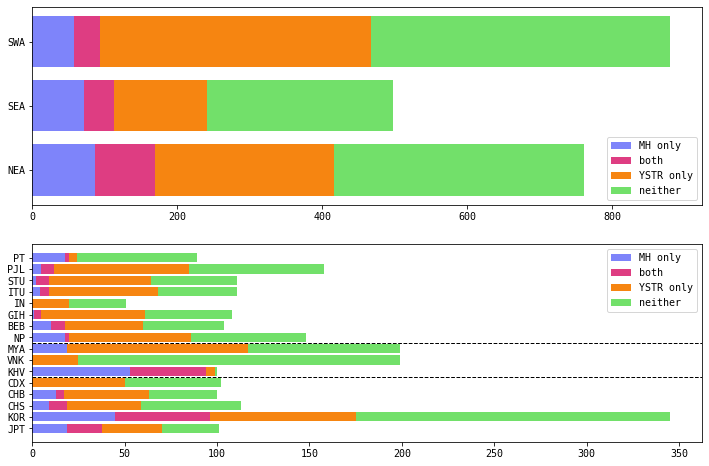

In [3]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 8))

ax = axs[0]
bottom = pd.Series(0, index=utils.regions)
for cd in ['MH only', 'both', 'YSTR only', 'neither']:
    height = reg_code_freqs.xs(cd, level=1).reindex(utils.regions, fill_value=0)
    ax.barh(
        utils.regions,
        height,
        left=bottom,
        label=cd
    )
    bottom += height
ax.legend()

ax = axs[1]
bottom = pd.Series(0, index=utils.popls)
for cd in ['MH only', 'both', 'YSTR only', 'neither']:
    height = pop_code_freqs.xs(cd, level=1).reindex(utils.popls, fill_value=0)
    ax.barh(
        utils.popls,
        height,
        left=bottom,
        label=cd
    )
    bottom += height
ax.axhline(y=4.5, xmin=0, xmax=1, color='k', linestyle='--', linewidth=1)
ax.axhline(y=7.5, xmin=0, xmax=1, color='k', linestyle='--', linewidth=1)
ax.legend()
plt.show(); plt.close()

In [4]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.base import BaseEstimator, TransformerMixin

class MHasSNP(BaseEstimator, TransformerMixin):
    mh_map = {'GA': 'AG', 'CA': 'AC', 'TA': 'AT', 'GC': 'CG', 'TC': 'CT', 'TG': 'GT', np.nan: 'NN'}
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.mh_ids_ = sorted({el.split(':')[0] for el in X.columns if ':' in el})
        return self
    
    def transform(self, X, y=None):
        result = dict()
        for mh_id, size in zip(self.mh_ids_, utils.mh_sizes):
            ser_1 = X[f'{mh_id}:1']
            ser_2 = X[f'{mh_id}:2']
            for i in range(size):
                ch_1, ch_2 = ser_1.str.get(i), ser_2.str.get(i)
                result[f'{mh_id}_{i}'] = (ch_1 + ch_2).map(lambda x: self.mh_map.get(x, x))
        result = pd.DataFrame(result)
        return result
    

class MHtoDist(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.mh_ids_ = sorted({el.split(':')[0] for el in X.columns if ':' in el})
        return self
    
    def transform(self, X, y=None):
        X_return = pd.DataFrame(
            np.zeros((X.shape[0], len(self.mh_ids_)) ), 
            index=X.index, columns=self.mh_ids_
        )
        for mh_id, size in zip(self.mh_ids_, utils.mh_sizes):
            ser_1 = X[f'{mh_id}:1']
            ser_2 = X[f'{mh_id}:2']
            for i in range(size):
                ch_1, ch_2 = ser_1.str.get(i), ser_2.str.get(i)
                X_return[mh_id] += (ch_1 != ch_2)
                X_return.loc[ser_1.str.contains('N').fillna(False), mh_id] = np.nan
        return X_return


class MHJoinPairs(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.mh_ids_ = sorted({el.split(':')[0] for el in X.columns if ':' in el})
        return self
    
    def transform(self, X, y=None):
        X_return = pd.DataFrame(
            np.zeros((X.shape[0], len(self.mh_ids_)) ), 
            index=X.index, columns=self.mh_ids_
        )
        for mh_id, size in zip(self.mh_ids_, utils.mh_sizes):
            ser_1 = X[f'{mh_id}:1']
            ser_2 = X[f'{mh_id}:2']
            ser_1 = ser_1.fillna('N'*size)
            ser_2 = ser_2.fillna('N'*size)
            X_return[mh_id] = ser_1 + ser_2
            X_return.loc[ser_1 > ser_2, mh_id] = ser_2 + ser_1
        return X_return
    
    def _substitute(self, series):
        result = series \
            .str.replace('A', 'Pu') \
            .str.replace('G', 'Pu') \
            .str.replace('C', 'Py') \
            .str.replace('T', 'Py')
        return result
    

class MHDistFromCenter(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.mh_ids_ = sorted({el.split(':')[0] for el in X.columns if ':' in el})
        self.centers_ = []
        for mh_id, size in zip(self.mh_ids_, utils.mh_sizes):
            ser_1 = X[f'{mh_id}:1']
            ser_2 = X[f'{mh_id}:2']
            most_freq = pd.concat([ser_1, ser_2], axis=0).value_counts().index[0]
            if 'N' in most_freq:
                raise ValueError('Too many missing values.')
            self.centers_.append( most_freq )
        return self
    
    def transform(self, X, y=None):
        X_return = pd.DataFrame(
            np.zeros((X.shape[0], df_mh.shape[1]) ), 
            index=X.index, columns=df_mh.columns
        )
        for mh_id, size, most_freq in zip(self.mh_ids_, utils.mh_sizes, self.centers_):
            ser_1 = X[f'{mh_id}:1']
            ser_2 = X[f'{mh_id}:2']
            ser_1 = ser_1.fillna('N'*size)
            ser_2 = ser_2.fillna('N'*size)
            for i in range(size):
                X_return[f'{mh_id}:1'] += ser_1.str.get(i) != most_freq[i]
                X_return[f'{mh_id}:2'] += ser_2.str.get(i) != most_freq[i]
            side_1 = X_return[f'{mh_id}:1'].copy()
            side_2 = X_return[f'{mh_id}:2'].copy()
            X_return[f'{mh_id}:1'] = np.minimum(side_1, side_2)
            X_return[f'{mh_id}:2'] = np.maximum(side_1, side_2)
            X_return.loc[ser_1.str.contains('N'), f'{mh_id}:1'] = np.nan
            X_return.loc[ser_2.str.contains('N'), f'{mh_id}:2'] = np.nan
        return X_return

    
class NanKBinsDiscretizer(BaseEstimator, TransformerMixin):
    def __init__(self, n_bins=5):
    #, encode='ordinal', strategy='quantile', subsample=None, random_state=None):
        self.n_bins = n_bins
        # self._kbins = KBinsDiscretizer(
        #     n_bins=n_bins, 
        #     encode=encode, 
        #     strategy=strategy, 
        #     subsample=subsample, 
        #     random_state=random_state
        # )
    
    def fit(self, X, y=None):
        n_bins = self.n_bins
        if isinstance(n_bins, int):
            n_bins = [n_bins for _ in range(X.shape[1])]
        self.bin_edges_ = [
            np.nanquantile(col, np.linspace(0, 1, n_bin+1)[1:-1]) 
            for n_bin, (_, col) in zip(n_bins, X.iteritems())
        ]
        return self

    def transform(self, X, y=None):
        result = X.copy()
        for num, key in enumerate(X.columns):
            result[key] = np.searchsorted(self.bin_edges_[num], X[key])
            result.loc[X[key].isna(), key] = result.loc[X[key].isna(), key] + 1
        return result

# model with column transformer (all in one dataset)

### Trial #1
All with one model

In [11]:
import itertools
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.metrics import accuracy_score

def get_model(use_mh=False, use_ystr=False, random_state=None):
    tfmers_columns = [
        (OrdinalEncoder(
            handle_unknown='use_encoded_value', unknown_value=4
        ), df_snp.columns)
    ]
    if use_mh:
        tfmers_columns.append(
            (make_pipeline(
                # MHasSNP(),
                # SimpleImputer(strategy='constant', fill_value='NN'),

                # MHtoDist(),
                # SimpleImputer(strategy='most_frequent'),
                # OrdinalEncoder(
                #     categories=[list(range(size+1)) + [np.nan] for size in utils.mh_sizes],
                #     # handle_unknown='use_encoded_value', unknown_value=6
                # )
                # MHJoinPairs(),
                # OrdinalEncoder(
                #     handle_unknown='use_encoded_value', unknown_value=-1
                # )
                MHDistFromCenter(),
                SimpleImputer(strategy='median'),
                FunctionTransformer(np.floor),
                OrdinalEncoder(
                    categories=[list(range(size+1)) for size, _ in itertools.product(utils.mh_sizes, 'bi')]
                )
                ), df_mh.columns)
        )
    if use_ystr:
        tfmers_columns.append(
            (make_pipeline(
                SimpleImputer(strategy='median'),
                FunctionTransformer(np.floor),
                OrdinalEncoder(
                    handle_unknown='use_encoded_value', unknown_value=-1
                ),
                FunctionTransformer(lambda x: x+1)
                # NanKBinsDiscretizer(3)
            ), df_str.columns)
        )
    model = make_column_transformer(
        *tfmers_columns,
        sparse_threshold=0
    )
    min_categories = [5 for _ in df_snp.columns]
    if use_mh:
        # min_categories += [2+size for size in utils.mh_sizes]
        # min_categories += [(2**(size-1))*(2**size -1) for size in utils.mh_sizes]
        min_categories += [size+1 for size, _ in itertools.product(utils.mh_sizes, 'bi')]
    if use_ystr:
        min_categories += [3 for _ in df_str.columns]
    model = make_pipeline(
        model,
        CategoricalNB(
            min_categories=min_categories
        )
    )
    return model


y = df_demo['Geographic region']
reg_has = df_demo['Geographic region'] + has
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

for use_mh, use_ystr in itertools.product((False, True), (False, True)):
    print(f'MH={use_mh}, Y-STR={use_ystr}', end='||')
print()
for train_idxs, val_idxs in skf.split(df_demo.index, reg_has):
    train_ids = snu_ids.iloc[train_idxs]
    val_ids = snu_ids.iloc[val_idxs]

    mask_train = snu_ids.isin(train_ids)
    mask_val = snu_ids.isin(val_ids)
    
    for use_mh, use_ystr in itertools.product((False, True), (False, True)):
        model = get_model(use_mh=use_mh, use_ystr=use_ystr)
        model.fit(df_all.loc[train_ids], y[train_ids])
        proba = pd.DataFrame(model.predict_proba(df_all.loc[val_ids]), index=val_ids)
        print(
            'accuracy:',
            f'{1e2*accuracy_score(y[val_ids], model[-1].classes_[proba.idxmax(axis=1)] ):.3f}%',
            end='||'
        )
    print()

MH=False, Y-STR=False||MH=False, Y-STR=True||MH=True, Y-STR=False||MH=True, Y-STR=True||
accuracy: 87.617%||accuracy: 87.850%||accuracy: 89.720%||accuracy: 89.953%||
accuracy: 88.084%||accuracy: 87.617%||accuracy: 87.150%||accuracy: 86.916%||
accuracy: 90.654%||accuracy: 89.953%||accuracy: 90.888%||accuracy: 90.421%||
accuracy: 87.850%||accuracy: 87.150%||accuracy: 87.617%||accuracy: 87.850%||
accuracy: 89.486%||accuracy: 88.318%||accuracy: 87.850%||accuracy: 88.551%||
accuracy: 88.318%||accuracy: 88.318%||accuracy: 88.785%||accuracy: 87.617%||
accuracy: 88.551%||accuracy: 88.318%||accuracy: 89.019%||accuracy: 88.084%||
accuracy: 86.449%||accuracy: 86.215%||accuracy: 86.449%||accuracy: 87.150%||
accuracy: 89.953%||accuracy: 89.019%||accuracy: 90.187%||accuracy: 89.720%||
accuracy: 88.084%||accuracy: 89.486%||accuracy: 88.551%||accuracy: 88.785%||


### Trial #2

restricted to samples WITH those parameters

In [6]:
import itertools
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import CategoricalNB
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.metrics import accuracy_score

# def get_model(use_mh=False, use_ystr=False, random_state=None):
#     tfmers_columns = [
#         (OrdinalEncoder(
#             handle_unknown='use_encoded_value', unknown_value=4
#         ), df_snp.columns)
#     ]
#     if use_mh:
#         tfmers_columns.append(
#             (make_pipeline(
#                 # MHasSNP(),
#                 # SimpleImputer(strategy='constant', fill_value='NN'),
#                 MHtoDist(),
#                 SimpleImputer(strategy='most_frequent'),
#                 OrdinalEncoder(
#                     handle_unknown='use_encoded_value', unknown_value=6
#                 )), df_mh.columns)
#         )
#     if use_ystr:
#         tfmers_columns.append(
#             (NanKBinsDiscretizer(4), df_str.columns),
#         )
#     model = make_column_transformer(
#         *tfmers_columns,
#         sparse_threshold=0
#     )
#     model = make_pipeline(
#         model,
#         CategoricalNB(
#             min_categories=7
#             # min_categories=\
#             # [5 for _ in df_snp.columns] + [7 for _ in mh_ids] + [5 for _ in df_str.columns]
#         )
#     )
#     return model


y = df_demo['Geographic region']
reg_has = df_demo['Geographic region'] + has
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for use_mh, use_ystr in itertools.product((False, True), (False, True)):
    print(f'MH={use_mh}, Y-STR={use_ystr}', end='||')
print()
for train_idxs, val_idxs in skf.split(df_demo.index, reg_has):
    train_ids = snu_ids.iloc[train_idxs]
    val_ids = snu_ids.iloc[val_idxs]

    mask_train = snu_ids.isin(train_ids) & mask_has_mh
    mask_val = snu_ids.isin(val_ids) & mask_has_mh
    
    for use_mh, use_ystr in itertools.product((False, True), (False, True)):
        model = get_model(use_mh=use_mh, use_ystr=use_ystr)
        model.fit(df_all[mask_train], y[mask_train])
        proba = pd.DataFrame(model.predict_proba(df_all.loc[mask_val]), index=mask_val.index[mask_val])
        print(
            'accuracy:',
            f'{1e2*accuracy_score(y[mask_val], model[-1].classes_[proba.idxmax(axis=1)] ):.3f}%',
            end='||'
        )
    print()

MH=False, Y-STR=False||MH=False, Y-STR=True||MH=True, Y-STR=False||MH=True, Y-STR=True||
accuracy: 90.667%||accuracy: 89.333%||accuracy: 90.667%||accuracy: 90.667%||
accuracy: 90.789%||accuracy: 89.474%||accuracy: 93.421%||accuracy: 93.421%||
accuracy: 94.667%||accuracy: 96.000%||accuracy: 90.667%||accuracy: 90.667%||
accuracy: 84.000%||accuracy: 86.667%||accuracy: 86.667%||accuracy: 90.667%||
accuracy: 92.000%||accuracy: 96.000%||accuracy: 93.333%||accuracy: 94.667%||


In [444]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
# from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
# from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, roc_auc_score

def get_model():
    model = make_pipeline(
        PCA(
            n_components=30,
            random_state=42,
        ),
        LogisticRegression(
            random_state=42
        )
        # QuadraticDiscriminantAnalysis()
    )
    return model


y = df_demo['Geographic region']
reg_has = df_demo['Geographic region'] + has
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idxs, val_idxs in skf.split(df_demo.index, reg_has):
    train_ids = snu_ids.iloc[train_idxs]
    val_ids = snu_ids.iloc[val_idxs]

    mask_train = snu_ids.isin(train_ids)
    mask_val = snu_ids.isin(val_ids)

    # model = CategoricalNB(
    #     fit_prior=False,
    #     min_categories=df_snp_ord.nunique().values
    # )
    model = get_model()
    # model.fit(df_snp_ord[mask_train], y[mask_train])
    model.fit(df_snp_onehot[mask_train], y[mask_train])
    # proba = pd.DataFrame(model.predict_proba(df_snp_ord[mask_val]), index=df_all.index[mask_val])
    proba = pd.DataFrame(model.predict_proba(df_snp_onehot[mask_val]), index=df_all.index[mask_val])
    print(
        1e2*accuracy_score(
            y[mask_val], model.classes_[proba.idxmax(axis=1)]
        ),
        1e2*roc_auc_score(
            y[mask_val], proba,
            average='macro', multi_class='ovr'
        )
    )
    
    model = CategoricalNB(
        fit_prior=False,
        min_categories=df_snp_ord_mh.nunique()
    )
    # model = get_model()
    model.fit(df_snp_ord_mh[mask_train & mask_has_mh], y[mask_train & mask_has_mh])
    # model.fit(df_snp_onehot_mh[mask_train & has_mh], y[mask_train & has_mh])
    proba_mh = pd.DataFrame(model.predict_proba(df_snp_ord_mh.loc[mask_val & mask_has_mh]), index=df_all.index[mask_val & mask_has_mh])
    # proba_mh = pd.DataFrame(model.predict_proba(df_snp_onehot_mh.loc[mask_val & has_mh]), index=df_all.index[mask_val & has_mh])
    proba_mh = proba_mh.reindex(proba.index, fill_value=0)

    proba_with_mh = proba + 1*proba_mh
    proba_with_mh = proba_with_mh.divide(proba_with_mh.sum(axis=1), axis=0)

    print(
        "\t",
        1e2*accuracy_score(
            y[mask_val], model.classes_[proba_with_mh.idxmax(axis=1)]
        ),
        1e2*roc_auc_score(
            y[mask_val], proba_with_mh,
            average='macro', multi_class='ovr'
        )
    )

85.04672897196261 95.23182394599793
	 85.51401869158879 95.59772831870767
88.78504672897196 97.09049692031635
	 89.01869158878505 97.23202347616314
85.74766355140187 95.61158354938355
	 86.44859813084112 96.00478378629714
85.98130841121495 95.0877621864708
	 87.14953271028037 95.60940752020105
84.30913348946136 95.36748416576474
	 85.01170960187353 95.97134692688037
